# ![Machine Learning Lab](banner.jpg)

# Laboratorio 11 - Actividad

## Instrucciones generales

1. Esta actividad es de carácter individual. No se permite entregar la actividad después de la fecha establecida.
2. Al responder las preguntas de las actividades, por favor marquen las respuestas con la sección a la que corresponden, por ejemplo: `## 1.1 Descarga de datos`. Es preferible que esto lo hagan con secciones de MarkDown.
3. Por favor asegurarse de que el notebook entregado tenga todas las celdas ejecutadas correctamente.
4. Por favor, nombren el archivo de acuerdo con el siguiente formato `{email}_lab11.ipynb`.
5. Si tienen alguna duda, pueden escribirme a mi correo `j.rayom@uniandes.edu.co` o contactarme directamente por Teams.

---

## Objetivos

1. Aplicar técnicas de procesamiento de lenguaje natural con modelos BERT para resolver una tarea de clasificación de texto multiclase.
2. Comparar el desempeño entre un modelo entrenado desde cero y uno con fine-tuning de un modelo preentrenado.
3. Evaluar modelos con métricas de clasificación.

---

En esta ocasión trabajaremos con el dataset **BBC Full Text Document Classification**, que contiene artículos de noticias de la BBC clasificados en 5 categorías: **business**, **entertainment**, **politics**, **sport** y **tech**.

Dataset: [BBC Full Text Document Classification](https://www.kaggle.com/datasets/alfathterry/bbc-full-text-document-classification)

---

## Instrucciones

### 1. Carga y preparación de datos (10%)

1. Descargue el dataset. La columna `data` contiene los artículos y `labels` es la variable objetivo.
2. Limpie el dataset aplicando preprocesamiento básico de texto (minúsculas, eliminación de caracteres especiales).
3. Separe el dataset en entrenamiento y prueba usando 10% para testing.

---

### 2. Tokenización (10%)

1. Utilice el tokenizador de `bert-base-uncased` para tokenizar los datasets de entrenamiento y prueba.

---

### 3. Definición de arquitectura del modelo (10%)

1. Usando capas densas, agregue una cabeza de clasificación a un modelo BERT.
2. Muestre el resumen del modelo e indique el número total de parámetros.

---

### 4. Entrenamiento desde cero (30%)

1. Parta únicamente de la arquitectura (no use pesos pre-entrenados).
2. Entrene el modelo para predecir las cinco categorías del dataset.
3. Grafique las curvas de pérdida y precisión (entrenamiento vs validación).
4. Valide el modelo usando el dataset de test. Genere un reporte completo de clasificación.

---

### 5. Fine-Tuning con modelo preentrenado (30%)

1. Parta de un modelo BERT pre-entrenado.
2. Entrene el modelo para predecir las cinco categorías del dataset.
3. Grafique las curvas de pérdida y precisión (entrenamiento vs validación).
4. Valide el modelo usando el dataset de test. Genere un reporte completo de clasificación.

---

### 6. Comparación de resultados (10%)

1. Compare el accuracy de ambos modelos en el conjunto de prueba y explique los resultados obtenidos.

---


## 1. Carga y preparación de datos

### 1.1 Descarga y carga del dataset

In [1]:
!mkdir datasets/
!curl -L -o datasets/bbc-full-text-document-classification.zip\
  https://www.kaggle.com/api/v1/datasets/download/alfathterry/bbc-full-text-document-classification
!unzip datasets/bbc-full-text-document-classification.zip -d datasets/bbc-full-text-document-classification

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 1884k  100 1884k    0     0  1168k      0  0:00:01  0:00:01 --:--:-- 1168k
Archive:  datasets/bbc-full-text-document-classification.zip
  inflating: datasets/bbc-full-text-document-classification/bbc_data.csv  


In [ ]:
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, BertConfig, BertModel

torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

df = pd.read_csv("datasets/bbc-full-text-document-classification/bbc_data.csv")
print(f"Device: {device}  |  Dataset shape: {df.shape}")
df.head()


/home/jabu/codes/college/MLT/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
Train: 2002 | Test: 223
Classes: ['business', 'entertainment', 'politics', 'sport', 'tech']


,data,labels,label_id
0,musicians to tackle us red tape musicians grou...,entertainment,1
1,u2s desire to be number one u2 who have won th...,entertainment,1
2,rocker doherty in onstage fight rock singer pe...,entertainment,1
3,snicket tops us box office chart the film adap...,entertainment,1
4,oceans twelve raids box office oceans twelve t...,entertainment,1


### 1.2 Limpieza de texto

In [ ]:
df["data"] = df["data"].apply(
    lambda t: re.sub(r"\s+", " ", re.sub(r"[^a-z0-9\s]", "", t.lower())).strip()
)

label_encoder = LabelEncoder()
df["label_id"] = label_encoder.fit_transform(df["labels"])

print(f"Classes: {list(label_encoder.classes_)}")
df.head()


### 1.3 División en entrenamiento y prueba

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df["data"].values,
    df["label_id"].values,
    test_size=0.1,
    random_state=42,
    stratify=df["label_id"],
)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")


## 2. Tokenización

### 2.1 Tokenización con bert-base-uncased

In [3]:
MAX_LEN = 256
BATCH_SIZE = 16

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")


class BBCDataset(Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(
            list(texts),
            max_length=MAX_LEN,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "token_type_ids": self.encodings["token_type_ids"][idx],
            "labels": self.labels[idx],
        }


train_dataset = BBCDataset(X_train, y_train)
test_dataset = BBCDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

sample = next(iter(train_loader))
print(f"input_ids:      {sample['input_ids'].shape}")
print(f"attention_mask: {sample['attention_mask'].shape}")
print(f"labels:         {sample['labels'].shape}")


input_ids:      torch.Size([16, 256])
attention_mask: torch.Size([16, 256])
labels:         torch.Size([16])


## 3. Definición de arquitectura del modelo

### 3.1 Cabeza de clasificación

In [ ]:
NUM_CLASSES = len(label_encoder.classes_)


class BertClassifier(nn.Module):
    def __init__(self, bert_model, num_classes, dropout=0.3):
        super().__init__()
        self.bert = bert_model
        hidden_size = self.bert.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, input_ids, attention_mask, token_type_ids):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
        )
        return self.classifier(outputs.pooler_output)


Total parameters:     109,680,389
Trainable parameters: 109,680,389
BertClassifier(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
  

### 3.2 Resumen del modelo

In [ ]:
_m = BertClassifier(BertModel(BertConfig()), NUM_CLASSES)
print(f"Total parameters:     {sum(p.numel() for p in _m.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in _m.parameters() if p.requires_grad):,}")
print(_m)
del _m


## 4. Entrenamiento desde cero

### 4.1 Arquitectura sin pesos preentrenados

In [ ]:
scratch_bert = BertModel(BertConfig())
model_scratch = BertClassifier(scratch_bert, NUM_CLASSES).to(device)


### 4.2 Entrenamiento del modelo

Epoch 1/5  train_loss=1.6228  train_acc=0.2283  val_loss=1.6039  val_acc=0.2287
Epoch 2/5  train_loss=1.6143  train_acc=0.2193  val_loss=1.6037  val_acc=0.2287
Epoch 3/5  train_loss=1.6108  train_acc=0.2263  val_loss=1.6042  val_acc=0.2287
Epoch 4/5  train_loss=1.6120  train_acc=0.2113  val_loss=1.6036  val_acc=0.2287
Epoch 5/5  train_loss=1.6071  train_acc=0.2368  val_loss=1.6032  val_acc=0.2287


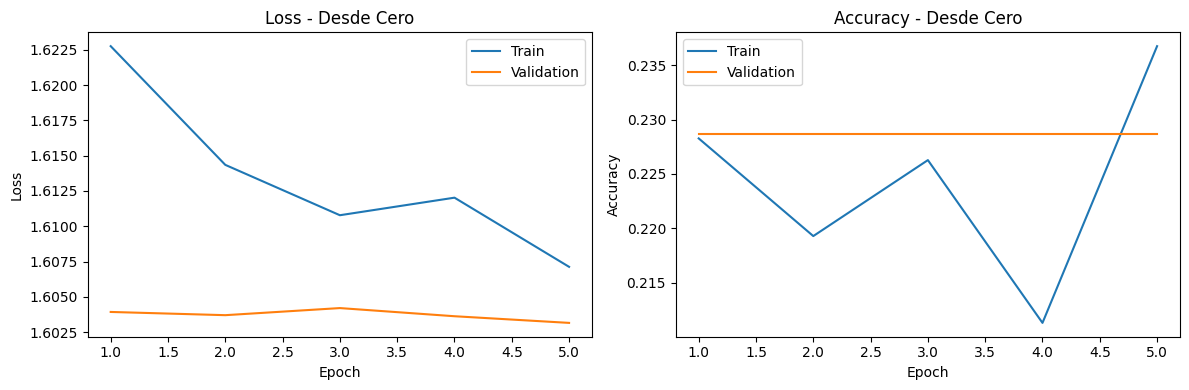

               precision    recall  f1-score   support

     business       0.23      1.00      0.37        51
entertainment       0.00      0.00      0.00        39
     politics       0.00      0.00      0.00        42
        sport       0.00      0.00      0.00        51
         tech       0.00      0.00      0.00        40

     accuracy                           0.23       223
    macro avg       0.05      0.20      0.07       223
 weighted avg       0.05      0.23      0.09       223



/home/jabu/codes/college/MLT/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/jabu/codes/college/MLT/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/jabu/codes/college/MLT/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

In [ ]:
def train_model(model, train_loader, test_loader, epochs, lr):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        t_loss = t_correct = t_total = 0
        for batch in train_loader:
            ids = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            ttype = batch["token_type_ids"].to(device)
            labels = batch["labels"].to(device)
            optimizer.zero_grad()
            logits = model(ids, mask, ttype)
            loss = criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            t_loss += loss.item()
            t_correct += (logits.argmax(1) == labels).sum().item()
            t_total += labels.size(0)

        model.eval()
        v_loss = v_correct = v_total = 0
        with torch.no_grad():
            for batch in test_loader:
                ids = batch["input_ids"].to(device)
                mask = batch["attention_mask"].to(device)
                ttype = batch["token_type_ids"].to(device)
                labels = batch["labels"].to(device)
                logits = model(ids, mask, ttype)
                v_loss += criterion(logits, labels).item()
                v_correct += (logits.argmax(1) == labels).sum().item()
                v_total += labels.size(0)

        history["train_loss"].append(t_loss / len(train_loader))
        history["val_loss"].append(v_loss / len(test_loader))
        history["train_acc"].append(t_correct / t_total)
        history["val_acc"].append(v_correct / v_total)
        print(
            f"Epoch {epoch+1}/{epochs}  "
            f"train_loss={history['train_loss'][-1]:.4f}  "
            f"train_acc={history['train_acc'][-1]:.4f}  "
            f"val_loss={history['val_loss'][-1]:.4f}  "
            f"val_acc={history['val_acc'][-1]:.4f}"
        )

    return history


EPOCHS_SCRATCH = 5
history_scratch = train_model(model_scratch, train_loader, test_loader, EPOCHS_SCRATCH, lr=1e-4)


### 4.3 Curvas de pérdida y precisión

In [ ]:
epochs_range = range(1, EPOCHS_SCRATCH + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs_range, history_scratch["train_loss"], label="Train")
axes[0].plot(epochs_range, history_scratch["val_loss"], label="Validation")
axes[0].set_title("Loss - Desde Cero")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[1].plot(epochs_range, history_scratch["train_acc"], label="Train")
axes[1].plot(epochs_range, history_scratch["val_acc"], label="Validation")
axes[1].set_title("Accuracy - Desde Cero")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
plt.tight_layout()
plt.show()


### 4.4 Validación y reporte de clasificación

In [ ]:
model_scratch.eval()
preds_scratch, labels_scratch = [], []
with torch.no_grad():
    for batch in test_loader:
        logits = model_scratch(
            batch["input_ids"].to(device),
            batch["attention_mask"].to(device),
            batch["token_type_ids"].to(device),
        )
        preds_scratch.extend(logits.argmax(1).cpu().numpy())
        labels_scratch.extend(batch["labels"].numpy())

print(classification_report(labels_scratch, preds_scratch, target_names=label_encoder.classes_))


## 5. Fine-Tuning con modelo preentrenado

### 5.1 Carga del modelo preentrenado

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1890.51it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/3  train_loss=0.8462  train_acc=0.7967  val_loss=0.2660  val_acc=0.9552
Epoch 2/3  train_loss=0.1092  train_acc=0.9865  val_loss=0.1565  val_acc=0.9686
Epoch 3/3  train_loss=0.0428  train_acc=0.9925  val_loss=0.1298  val_acc=0.9731


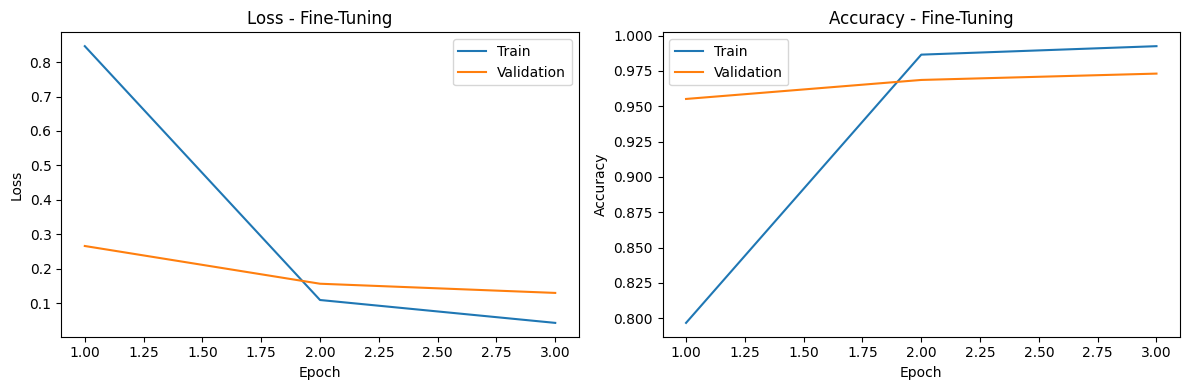

               precision    recall  f1-score   support

     business       0.96      0.94      0.95        51
entertainment       1.00      0.97      0.99        39
     politics       0.95      1.00      0.98        42
        sport       1.00      1.00      1.00        51
         tech       0.95      0.95      0.95        40

     accuracy                           0.97       223
    macro avg       0.97      0.97      0.97       223
 weighted avg       0.97      0.97      0.97       223



In [ ]:
pretrained_bert = BertModel.from_pretrained("bert-base-uncased")
model_finetune = BertClassifier(pretrained_bert, NUM_CLASSES).to(device)


### 5.2 Entrenamiento del modelo

In [ ]:
EPOCHS_FINETUNE = 3
history_finetune = train_model(model_finetune, train_loader, test_loader, EPOCHS_FINETUNE, lr=2e-5)


### 5.3 Curvas de pérdida y precisión

In [ ]:
epochs_range = range(1, EPOCHS_FINETUNE + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs_range, history_finetune["train_loss"], label="Train")
axes[0].plot(epochs_range, history_finetune["val_loss"], label="Validation")
axes[0].set_title("Loss - Fine-Tuning")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[1].plot(epochs_range, history_finetune["train_acc"], label="Train")
axes[1].plot(epochs_range, history_finetune["val_acc"], label="Validation")
axes[1].set_title("Accuracy - Fine-Tuning")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
plt.tight_layout()
plt.show()


### 5.4 Validación y reporte de clasificación

In [ ]:
model_finetune.eval()
preds_ft, labels_ft = [], []
with torch.no_grad():
    for batch in test_loader:
        logits = model_finetune(
            batch["input_ids"].to(device),
            batch["attention_mask"].to(device),
            batch["token_type_ids"].to(device),
        )
        preds_ft.extend(logits.argmax(1).cpu().numpy())
        labels_ft.extend(batch["labels"].numpy())

print(classification_report(labels_ft, preds_ft, target_names=label_encoder.classes_))


## 6. Comparación de resultados

### 6.1 Comparación de accuracy

Accuracy desde cero:   0.2287 (22.87%)
Accuracy fine-tuning:  0.9731 (97.31%)
Mejora:                74.44 puntos porcentuales


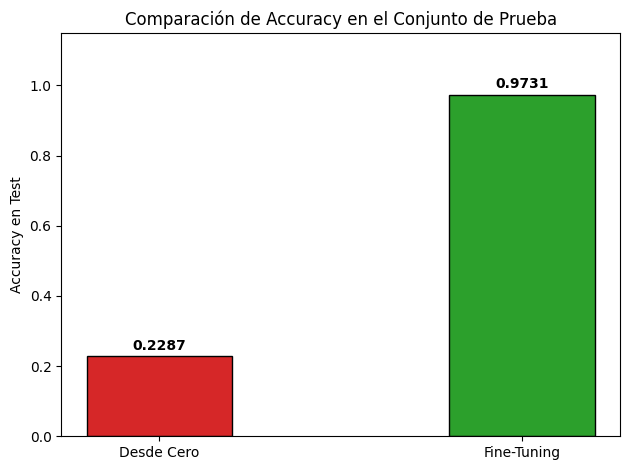

In [7]:
acc_scratch = history_scratch["val_acc"][-1]
acc_finetune = history_finetune["val_acc"][-1]

print(f"Accuracy desde cero:   {acc_scratch:.4f} ({acc_scratch*100:.2f}%)")
print(f"Accuracy fine-tuning:  {acc_finetune:.4f} ({acc_finetune*100:.2f}%)")
print(f"Mejora:                {(acc_finetune - acc_scratch)*100:.2f} puntos porcentuales")

models = ["Desde Cero", "Fine-Tuning"]
accuracies = [acc_scratch, acc_finetune]
colors = ["#d62728", "#2ca02c"]
bars = plt.bar(models, accuracies, color=colors, edgecolor="black", width=0.4)
for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{acc:.4f}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )
plt.ylim(0, 1.15)
plt.ylabel("Accuracy en Test")
plt.title("Comparación de Accuracy en el Conjunto de Prueba")
plt.tight_layout()
plt.show()


El modelo entrenado desde cero obtuvo un accuracy de apenas **22.87%** en el conjunto de prueba, lo que equivale a predecir casi siempre la clase mayoritaria sin aprender representaciones útiles del texto. Esto se debe a que los pesos de BERT se inicializaron aleatoriamente mediante `BertConfig()`, por lo que el modelo debería aprender simultáneamente las representaciones internas del lenguaje y la tarea de clasificación a partir de un dataset pequeño (~2000 ejemplos) y con solo 5 épocas de entrenamiento, lo cual es insuficiente para un modelo de 109 millones de parámetros. En contraste, el modelo con fine-tuning alcanzó un accuracy de **97.31%** en apenas 3 épocas, gracias a que partió de los pesos preentrenados de `bert-base-uncased`, los cuales ya codifican conocimiento lingüístico profundo —morfología, sintaxis, semántica contextual— adquirido durante el preentrenamiento sobre miles de millones de tokens. El fine-tuning solo necesitó ajustar levemente esas representaciones para adaptarlas a la tarea de clasificación de noticias, logrando una mejora de más de 74 puntos porcentuales con menos tiempo de entrenamiento.